In [11]:
import pickle
import numpy as np
from pathlib import Path
from tqdm import tqdm
from vebir.pca import loo_pca, malinowski_ind, pca
from vebir.ebs import EBS
from vebir.veb import VEB, norm_cdf, norm_pdf, pinball_loss, als_loss, pb_map, als_map
from vebir.metrics_utils import compute_compound_cors, compute_method_cors
import pandas as pd 
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import cvxpy as cp

from scipy.linalg import svd

In [12]:
REPO_ROOT = Path.cwd().resolve().parent
PREPROC_DIR = REPO_ROOT / "data" / "preprocessed" / "teflon"

GT_DIR = REPO_ROOT / "data" / "spectrabase" / "teflon"
LAB_DIR = REPO_ROOT / "data" / "raw" / "teflon" / "laboratory_samples"
PREPROC_DIR = REPO_ROOT / "data" / "preprocessed" / "teflon"
CORRECTIONS_DIR = REPO_ROOT / "data" / "corrections" / "teflon" / "ebs"

with open(PREPROC_DIR / "blanks_dict.pkl", "rb") as f:
    blanks_dict = pickle.load(f)

with open(PREPROC_DIR / "raw_spectra_dict.pkl", "rb") as f:
    raw_spectra_dict = pickle.load(f)

with open(GT_DIR / "ref_dict.pkl", "rb") as file:
    ref_dict = pickle.load(file)
    
with open(PREPROC_DIR / "spectra_responses.pkl", "rb") as f:
    spectra_responses = pickle.load(f)

CO2 = ref_dict["CO2"]
H2O = np.array(pd.read_csv("../data/spectrabase/teflon/H2O_spectrum.csv"))

del ref_dict["CO2"]

wn = np.sort(pd.read_csv(LAB_DIR / "zerofilling.txt", header=None).iloc[:, 0])

In [92]:
from itertools import product

In [120]:
class MapCV:
    def __init__(
        self,
        y,
        mu,
        W,
        loss="PB",
        sigma_init=0.0001,
        tau_grid=[0.1],
        c_grid=[10],
        num_folds=5,
    ):
        self.loss = loss
        self.sigma_init = sigma_init
        self.num_folds = num_folds
        self.tau_grid = tau_grid
        self.c_grid = c_grid
        self.y = y
        self.mu = mu
        self.W = W
        self.folds = np.array_split(np.arange(y.shape[0]), num_folds)
        
        if self.loss == "ALS":
            self.loss_fun = als_loss
            self.comp_map = als_map
        if self.loss == "PB":
            self.loss_fun = pinball_loss
            self.comp_map = pb_map

    def compute_cv_err(self, tau, c, sigma):
        a = np.zeros(self.y.shape[0])
        for fold in self.folds:
            keep_idx = np.concatenate([f for f in self.folds if f is not fold])
            _, x = self.comp_map(
                self.y[keep_idx],
                self.mu[keep_idx],
                self.W[keep_idx, :c],
                tau=tau,
                sigma=sigma,
            )
            a[fold] = self.y[fold] - (self.mu[fold] + self.W[fold, : c] @ x)

        return np.sum(self.loss_fun(a, tau=tau))

    def local_searches_sigma(self, tau, c, sigma, mit=100):
        break_loop = False
        
        prev_loss_val = self.compute_cv_err(tau, c, sigma)
        loss_low = self.compute_cv_err(tau, c, sigma / 2)
        loss_high = self.compute_cv_err(tau, c, sigma * 2)

        prev_sigma = sigma
        if prev_loss_val <= min(loss_low, loss_high):
            break_loop = True
            current_loss_val = prev_loss_val
        elif loss_low < loss_high:
            current_loss_val = loss_low
            sigma /= 2
        else:
            current_loss_val = loss_high
            sigma *= 2
        
        m = 0    
        while not break_loop:
            if sigma > prev_sigma:
                sigma_new = sigma * 2
            else:
                sigma_new = sigma / 2
        
            prev_sigma = sigma
            prev_loss_val = current_loss_val
            current_loss_val = self.compute_cv_err(tau, c, sigma_new)
            
            if current_loss_val < prev_loss_val:
                sigma = sigma_new
            else:
                current_loss_val = prev_loss_val
                break_loop = True
                
            m += 1    
            if m == mit:
                break_loop = True
       
        return sigma, current_loss_val
    
    def compute_cv_errs(self, mit=100, verbose=False):
        self.cv_errs = np.zeros((len(self.tau_grid), len(self.c_grid)))
        self.best_sigma = np.zeros((len(self.tau_grid), len(self.c_grid)))
        
        idx_pairs = list(
            product(range(self.cv_errs.shape[0]), range(self.cv_errs.shape[1]))
        )

        for i, j in tqdm(idx_pairs, disable=not verbose):    
            sigma, current_loss_val = self.local_searches_sigma(
                self.tau_grid[i], self.c_grid[j], self.sigma_init, mit=mit
            )

            self.cv_errs[i, j] = current_loss_val
            self.best_sigma[i, j] = sigma
            
        row_idx, col_idx = np.unravel_index(np.argmin(self.cv_errs), self.cv_errs.shape)
        self.opt_tau = self.tau_grid[row_idx]
        self.opt_c = self.c_grid[col_idx]
        self.opt_sigma = self.best_sigma[row_idx, col_idx]

    def map(self, mit=100):
        self.interference, self.x = self.comp_map(
            self.y,
            self.mu,
            self.W[:, : self.opt_c],
            self.opt_tau,
            self.opt_sigma,
            mit,
            verbose=False,
        )
        self.absorbance = self.y - self.interference


In [121]:
Z = np.array(blanks_dict["2011"])
Y = np.array(raw_spectra_dict["Ammonium sulfate"]["raw"])
mu,_,_,W = pca(Z)

In [149]:
mod = MapCV(Y[5,:], mu, W, loss="PB", num_folds=5,tau_grid=[0.025,0.05,0.1,0.2,0.4], c_grid=[47])

In [150]:
mod.compute_cv_errs(mit=100,verbose=True)

100%|██████████| 5/5 [00:35<00:00,  7.10s/it]


In [151]:
print(mod.opt_tau, mod.opt_c, mod.opt_sigma, mod.cv_errs.min())

0.025 47 0.0002 2.3314828613853664


In [152]:
mod.compute_cv_err(tau=mod.opt_tau, c=mod.opt_c, sigma=mod.opt_sigma)

np.float64(2.3314828613853664)

In [153]:
mod.map(mit=100)

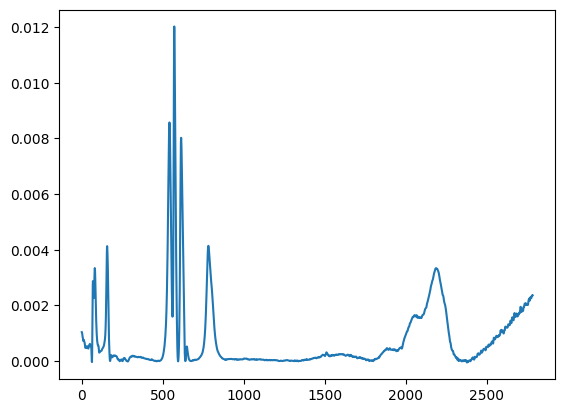

In [154]:
plt.plot(mod.absorbance)

In [114]:
mod.best_sigma

array([[3.90625e-07]])

In [115]:
mod.cv_errs

array([[1.50699671]])

In [22]:
mod.initialize()
mod.search(mit=100)

In [23]:
mod.map()

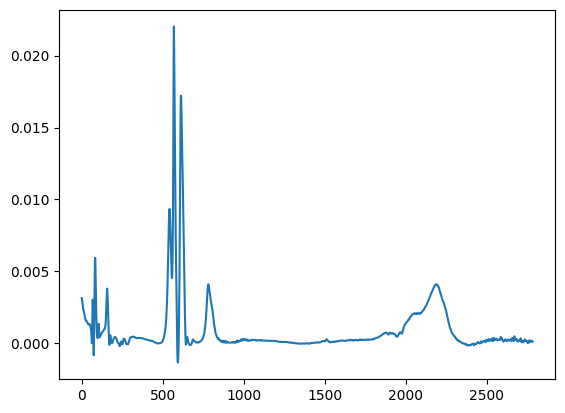

In [24]:
plt.plot(mod.absorbance)

In [61]:
with open(CORRECTIONS_DIR / "pb_fixed.pkl", "rb") as f:
    ebs_cv_pb_dict = pickle.load(f)

In [62]:
ebs_cv_pb_dict

{'1-Docosanol': [{'absorbance': array([0.00136894, 0.00123841, 0.00088939, ..., 0.00034032, 0.00037928,
          0.00038911], shape=(2785,)),
   'time': 3.2816805839538574,
   'opt_tau': 0.1,
   'opt_c': np.int64(47),
   'cv_errs': array([[5.35999786]])},
  {'absorbance': array([0.00304772, 0.00281537, 0.00222123, ..., 0.00059598, 0.00069236,
          0.00074454], shape=(2785,)),
   'time': 3.1521286964416504,
   'opt_tau': 0.1,
   'opt_c': np.int64(47),
   'cv_errs': array([[10.50388434]])},
  {'absorbance': array([0.01472056, 0.01302385, 0.00837692, ..., 0.00429372, 0.00543877,
          0.00548324], shape=(2785,)),
   'time': 3.038940906524658,
   'opt_tau': 0.1,
   'opt_c': np.int64(47),
   'cv_errs': array([[54.83383251]])}],
 '1-Docosanol|Adipic Acid': [{'absorbance': array([0.00624406, 0.00550956, 0.00353515, ..., 0.0016935 , 0.00209361,
          0.00196278], shape=(2785,)),
   'time': 3.9258599281311035,
   'opt_tau': 0.1,
   'opt_c': np.int64(47),
   'cv_errs': array([[14.9

In [63]:
ebs_cv_pb_dict

{'1-Docosanol': [{'absorbance': array([0.00136894, 0.00123841, 0.00088939, ..., 0.00034032, 0.00037928,
          0.00038911], shape=(2785,)),
   'time': 3.2816805839538574,
   'opt_tau': 0.1,
   'opt_c': np.int64(47),
   'cv_errs': array([[5.35999786]])},
  {'absorbance': array([0.00304772, 0.00281537, 0.00222123, ..., 0.00059598, 0.00069236,
          0.00074454], shape=(2785,)),
   'time': 3.1521286964416504,
   'opt_tau': 0.1,
   'opt_c': np.int64(47),
   'cv_errs': array([[10.50388434]])},
  {'absorbance': array([0.01472056, 0.01302385, 0.00837692, ..., 0.00429372, 0.00543877,
          0.00548324], shape=(2785,)),
   'time': 3.038940906524658,
   'opt_tau': 0.1,
   'opt_c': np.int64(47),
   'cv_errs': array([[54.83383251]])}],
 '1-Docosanol|Adipic Acid': [{'absorbance': array([0.00624406, 0.00550956, 0.00353515, ..., 0.0016935 , 0.00209361,
          0.00196278], shape=(2785,)),
   'time': 3.9258599281311035,
   'opt_tau': 0.1,
   'opt_c': np.int64(47),
   'cv_errs': array([[14.9

In [64]:
corrections_dict = {}
for comp in ref_dict:
    corrections_dict[comp] = np.array(
        [i["absorbance"] for i in ebs_cv_pb_dict[comp]]
    )

cors_dict = compute_method_cors(corrections_dict, ref_dict, wn)

In [65]:
cors_dict

{'12-Tricosanone': {'compound': '12-Tricosanone',
  'mean': np.float64(87.07316291197112),
  'std_err': np.float64(0.27498386230230054)},
 'Ammonium sulfate': {'compound': 'Ammonium sulfate',
  'mean': np.float64(81.25190413714046),
  'std_err': np.float64(0.21277626579112627)},
 'Malonic Acid': {'compound': 'Malonic Acid',
  'mean': np.float64(69.75956181347054),
  'std_err': np.float64(0.7266494041433381)},
 'Suberic Acid': {'compound': 'Suberic Acid',
  'mean': np.float64(67.35651448965629),
  'std_err': np.float64(0.5439354908405066)},
 'D-Glucose': {'compound': 'D-Glucose',
  'mean': np.float64(68.68795553046911),
  'std_err': np.float64(1.9498590262041844)},
 'fructose': {'compound': 'fructose',
  'mean': np.float64(84.24229639883646),
  'std_err': np.float64(0.8339625973096048)},
 'levoglucosan': {'compound': 'levoglucosan',
  'mean': np.float64(81.72079074968943),
  'std_err': np.float64(1.7648276219472936)},
 'all': {'compound': 'all',
  'mean': np.float64(79.73206788293908),


In [3]:
Z = np.array(blanks_dict["2011"])
Y = np.array(raw_spectra_dict["Ammonium sulfate"]["raw"])
mu,_,_,W = pca(Z)

In [4]:
y = Y[5,:] 

In [5]:
num_folds = 5

In [6]:
folds = np.array_split(np.arange(y.shape[0]), num_folds)

In [7]:
from vebir.ebs import ebs_pb, ebs_als
from vebir.veb import pinball_loss, als_loss

In [8]:
fold = folds[0]
keep_idx = np.concatenate([f for f in folds if f is not fold])

In [9]:

c = 10
tau = 0.001

In [10]:
chat = np.argmin(cv_err) + 1

NameError: name 'cv_err' is not defined

In [11]:
z, x = ebs_pb((y-mu),W[:,:chat],tau = tau)

NameError: name 'chat' is not defined

In [12]:
a = y - mu - z

NameError: name 'z' is not defined

In [13]:
plt.plot(a)

NameError: name 'a' is not defined

In [14]:
a[fold] = y[fold] - (mu[fold] + W[fold, :] @ x)

NameError: name 'x' is not defined

In [15]:
plt.plot(a)

NameError: name 'a' is not defined

In [16]:
plt.plot(a)

NameError: name 'a' is not defined

In [17]:
from vebir.ebs import ebs_pb, ebs_als
from vebir.veb import pinball_loss, als_loss
from itertools import product



In [ ]:

cv_err = []
for c in range(1,W.shape[1]+1):
    for fold in folds:
        keep_idx = np.concatenate([f for f in folds if f is not fold])
        _, x = ebs_pb((y-mu)[keep_idx],W[keep_idx,:c],tau = tau)
        a[fold] = y[fold] - (mu[fold] + W[fold, :c] @ x)
    cv_err.append(np.sum(pinball_loss(a, tau=tau)))
    print(f"c = {c}, cv error = {cv_err[-1]}")

AttributeError: 'EbsCV' object has no attribute 'compute_cv_errors'

In [18]:
class EbsCV:
    def __init__(
        self,
        y,
        mu,
        W,
        loss="PB",
        tau_grid=[0.1],
        num_folds=5,
    ):
        self.loss = loss
        self.num_folds = num_folds
        
        self.tau_grid =  tau_grid
        self.c_grid = np.arange(1, W.shape[1] + 1)
        self.y = y
        self.mu = mu
        self.W = W
        self.folds = np.array_split(np.arange(y.shape[0]), num_folds)
        
        if self.loss == "ALS":
            self.loss_fun = als_loss
            self.interference_estimator = ebs_als
        if self.loss == "PB":
            self.loss_fun = pinball_loss
            self.interference_estimator = ebs_pb
            
            
    def compute_cv_errors(self,verbose=False):
        self.cv_errs = np.zeros((len(self.tau_grid), len(self.c_grid)))
        idx_pairs = list(product(range(self.cv_errs.shape[0]), range(self.cv_errs.shape[1])))
            
        for i, j in tqdm(idx_pairs,disable=not verbose):
            a = np.zeros(y.shape[0])
            c = self.c_grid[j]
            tau = self.tau_grid[i]

            for fold in self.folds:
                keep_idx = np.concatenate([f for f in self.folds if f is not fold])
                _, x = self.interference_estimator((self.y-self.mu)[keep_idx],self.W[keep_idx,:c],tau = tau)
                a[fold] = self.y[fold] - (self.mu[fold] + self.W[fold, :c] @ x)

            self.cv_errs[i, j] = np.sum(self.loss_fun(a, tau=tau))
        
        row_idx, col_idx = np.unravel_index(np.argmin(self.cv_errs), self.cv_errs.shape)
        self.opt_tau = self.tau_grid[row_idx]
        self.opt_c = self.c_grid[col_idx]
        
    def estimate_absorbance(self,mit=100):
        self.z, self.x = self.interference_estimator((self.y-self.mu),self.W[:,:self.opt_c],tau = self.opt_tau,mit=mit)
        self.interference = self.mu + self.z
        self.absorbance = self.y - self.interference


In [23]:
Y = np.array(raw_spectra_dict["Ammonium sulfate"]["raw"])

In [24]:
tau_grid = [0.1]

In [29]:
for i in range(Y.shape[0]):
    mod = EbsCV(Y[i,:], mu, W, num_folds=5, tau_grid=tau_grid)
    mod.compute_cv_errors(verbose=True)
    mod.estimate_absorbance()

100%|██████████| 54/54 [00:42<00:00,  1.26it/s]


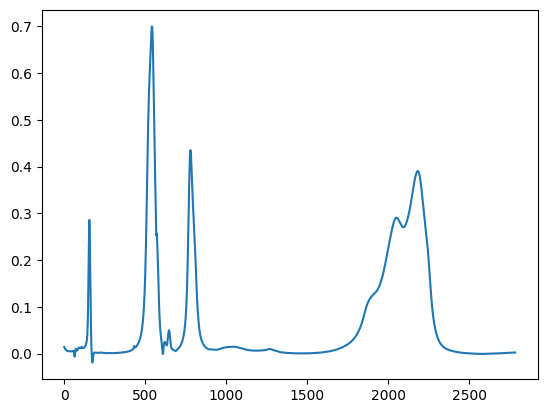

In [30]:
plt.plot(mod.absorbance)

In [143]:
mod.opt_c

np.int64(9)

In [144]:
mod.opt_tau

np.float64(0.025)

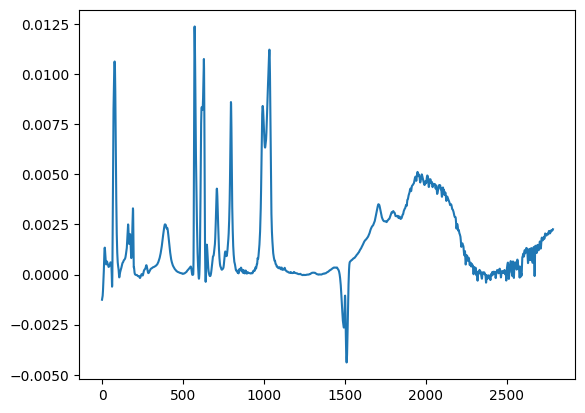

In [129]:
plt.plot(mod.absorbance)

In [136]:
mod.opt_tau

np.float64(0.05)

In [73]:
cv_err = []
for c in range(1,W.shape[1]+1):
    for fold in folds:
        keep_idx = np.concatenate([f for f in folds if f is not fold])
        _, x = ebs_pb((y-mu)[keep_idx],W[keep_idx,:c],tau = tau)
        a[fold] = y[fold] - (mu[fold] + W[fold, :c] @ x)
    cv_err.append(np.sum(pinball_loss(a, tau=tau)))

KeyboardInterrupt: 

In [ ]:
class MapCV:
    def __init__(
        self,
        y,
        mu,
        W,
        loss="PB",
        sigma=0.0001,
        tau=0.1,
        num_folds=5,
    ):
        self.loss = loss
        self.sigma = sigma
        self.num_folds = num_folds
        self.tau = tau
        self.y = y
        self.mu = mu
        self.W = W
        self.folds = np.array_split(np.arange(y.shape[0]), num_folds)

        self.prev_sigma = None
        self.current_loss_val = None
        self.prev_loss_val = None
        self.break_loop = False

        if self.loss == "ALS":
            self.loss_fun = als_loss
            self.comp_map = als_map
        if self.loss == "PB":
            self.loss_fun = pinball_loss
            self.comp_map = pb_map

    def compute_cv_err(self, sigma):
        a = np.zeros(self.y.shape[0])
        for fold in self.folds:
            keep_idx = np.concatenate([f for f in self.folds if f is not fold])
            _, x = self.comp_map(
                self.y[keep_idx],
                self.mu[keep_idx],
                self.W[keep_idx, :],
                tau=self.tau,
                sigma=sigma,
            )
            a[fold] = self.y[fold] - (self.mu[fold] + self.W[fold, :] @ x)

        return np.sum(self.loss_fun(a, tau=self.tau))

    def initialize(self):
        self.prev_loss_val = self.compute_cv_err(self.sigma)
        loss_low = self.compute_cv_err(self.sigma / 2)
        loss_high = self.compute_cv_err(self.sigma * 2)

        self.prev_sigma = self.sigma
        if loss_low < loss_high:
            self.current_loss_val = loss_low
            self.sigma /= 2
        else:
            self.current_loss_val = loss_high
            self.sigma *= 2

    def search(self, mit=100):
        m = 0
        while not self.break_loop:
            if self.sigma > self.prev_sigma:
                sigma_new = self.sigma * 2
            else:
                sigma_new = self.prev_sigma / 2

            self.prev_sigma = self.sigma
            self.sigma = sigma_new
            self.prev_loss_val = self.current_loss_val
            self.current_loss_val = self.compute_cv_err(self.sigma)
            m += 1
            if m == mit or self.current_loss_val > self.prev_loss_val:
                self.break_loop = True

        self.sigma = self.prev_sigma
        self.current_loss_val = self.prev_loss_val

    def map(self, mit=100):
        self.interference, self.x = self.comp_map(
            self.y,
            self.mu,
            self.W,
            self.tau,
            self.sigma,
            mit,
            verbose=False,
        )
        self.absorbance = self.y - self.interference

In [ ]:

    mod = VEB(c=W.shape[1], loss="PB")

In [31]:
from vebir.veb import VEB

In [32]:
A = []
for j in tqdm(range(Y.shape[0])):
    y = Y[j,:]
    mu,_,_,W = pca(Z)
    mod = VEB(c=W.shape[1], loss="PB")
    
    mod.fit(y,mu,W,mit=10000)
    best_elbo = mod.elbo
    best_tau = mod.tau
    best_c = mod.c
    best_sigma = mod.sigma_hat
    mod.map(y,mu,W)

    for i in range(W.shape[1]-1):
        remove_idx = np.argmin(np.abs(mod.nu/mod.d))
        
        W = np.delete(W, remove_idx, axis=1)
        mod.c = W.shape[1]
        mod.tau_init = mod.tau
        mod.nu_init = np.delete(mod.nu, remove_idx)
        mod.d_init = np.delete(mod.d, remove_idx)
        mod.fit(y,mu,W,mit=10000) 
        
        
        if mod.elbo > best_elbo:
            best_elbo = mod.elbo
            best_tau = mod.tau
            best_c = mod.c
            best_sigma = mod.sigma_hat
            mod.map(y,mu,W)
            
    A.append(mod.absorbance)

100%|██████████| 24/24 [05:52<00:00, 14.68s/it]


In [35]:
np.mean([np.corrcoef(np.interp(ref_dict["Suberic Acid"][:,0],wn,i), ref_dict["Suberic Acid"][:,1])[0,1] for i in A])

np.float64(0.8157468779403083)

In [36]:
best_c

20

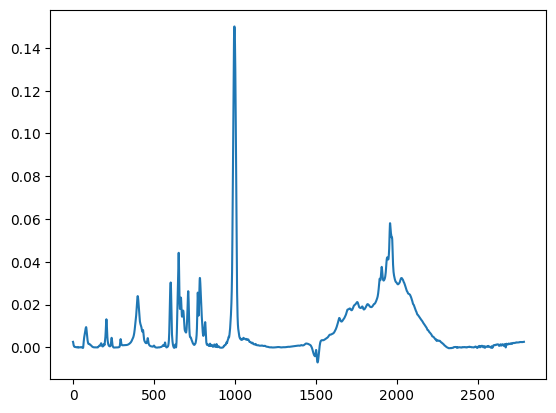

In [38]:
plt.plot(A[-1])

In [241]:
best_elbo

np.float64(6965.920122160984)

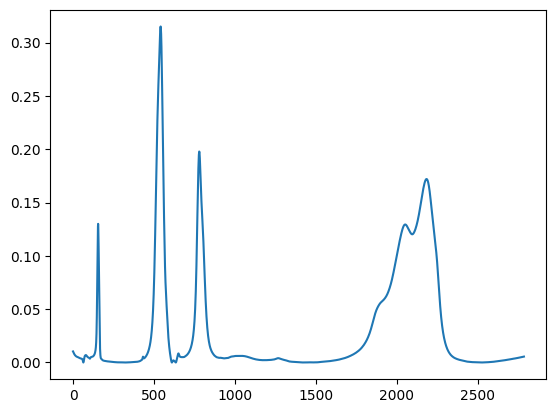

In [242]:
plt.plot(mod.absorbance)

In [243]:

best_c

10

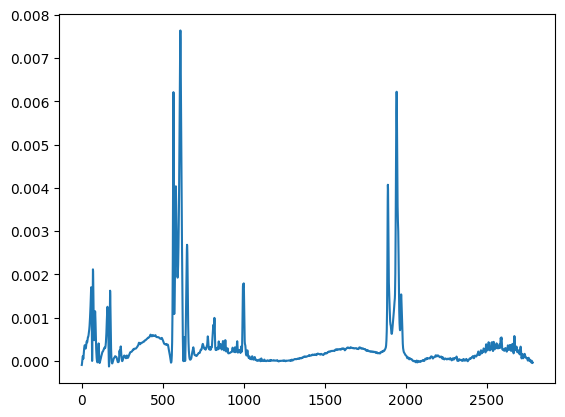

In [160]:
plt.plot(mod.absorbance)

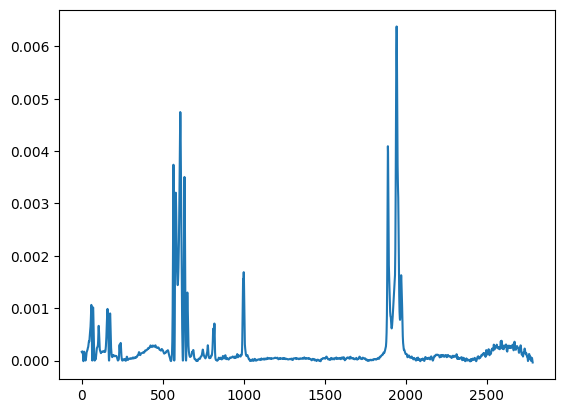

In [85]:
plt.plot(mod.absorbance)

In [86]:
mod.c

24

In [49]:
mod.elbo

np.float64(18223.06438796758)

In [ ]:
target_lot = "2011"

    
for key in blanks_dict:
    blanks_dict[key] = np.array(blanks_dict[key])
    
Z_target = blanks_dict[target_lot]
del blanks_dict[target_lot]

Z = []
for key in blanks_dict:
    mu = np.mean(blanks_dict[key], axis=0)
    sd = np.std(blanks_dict[key], axis=0)
    Z.append((blanks_dict[key] - mu) / sd)
Z = np.concatenate(Z, axis=0)

In [29]:
len(Z)

508

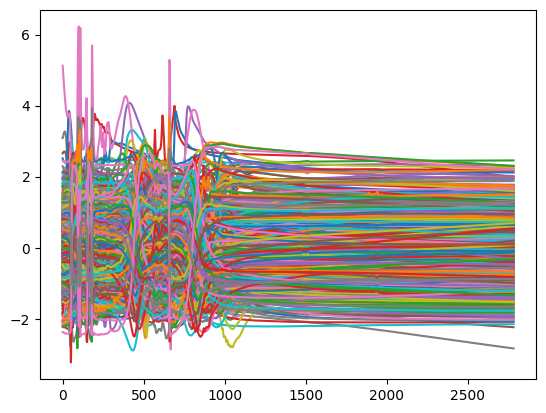

In [6]:
for i in range(len(Z)):
    plt.plot(Z[i])

In [36]:
def pca_scan(Z, Zte, mu_te, sd_te, max_ncomp=53):
   
    _, lam, V = svd(Z, full_matrices=False)
    V = V.T

    Zte_scaled = (Zte - mu_te) / sd_te

    Err = []
    for i in range(max_ncomp):
        Zhat = mu_te + sd_te * Zte_scaled @ V[:, : (i + 1)] @ V[:, : (i + 1)].T
        Err.append(np.mean((Zte - Zhat) ** 2))

    return np.array(Err)

In [40]:
Err = []
for i in range(Z_target.shape[0]):
    Zte = Z_target[[i], :]
    Zd = np.delete(Z_target, i, axis=0)
    mu_te, sd_te = np.mean(Zd, axis=0), np.std(Zd, axis=0)
    Zd = (Zd - mu_te) / sd_te
    Err.append(pca_scan(np.vstack([Zd,Z]), Zte, mu_te, sd_te, max_ncomp=561))


In [41]:
Err = np.array(Err)

m = np.mean(Err, axis=0)
se = np.std(Err, axis=0) / np.sqrt(Err.shape[0])

chat_min = 1 + np.argmin(m)
chat_ose = 1 + np.min(np.where(m - se <= np.min(m))[0])

print(chat_ose)

510


In [43]:
Zd = Z_target
mu_te, sd_te =np.mean(Zd, axis=0), np.std(Zd, axis=0)
Zd = (Zd - mu_te) / sd_te

In [55]:
_, lam, V = svd(np.vstack([Zd,Z]), full_matrices=False)

In [68]:
mu = mu_te
W = (V.T * lam) / np.sqrt(Z.shape[0] + Zd.shape[0])
W = W[:, :chat_ose]
W = (W.T * sd_te).T

In [71]:
mod = VEB(c=W.shape[1], loss="PB")

In [125]:
comp = "Malonic Acid"
Y = np.array(raw_spectra_dict[comp]["raw"])

In [126]:
mod.fit(Y[-1, :], mu, W,mit=2000)


In [127]:
mod.map(Y[12, :], mu, W)

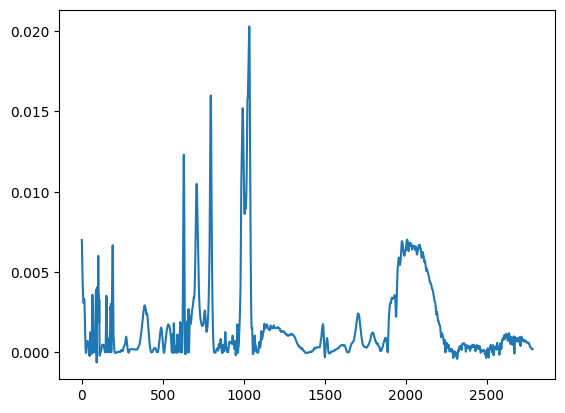

In [128]:
plt.plot(mod.absorbance)

In [115]:
with open(CORRECTIONS_DIR / "veb_pb_dict.pkl", "rb") as f:
    veb_pb_dict = pickle.load(f)

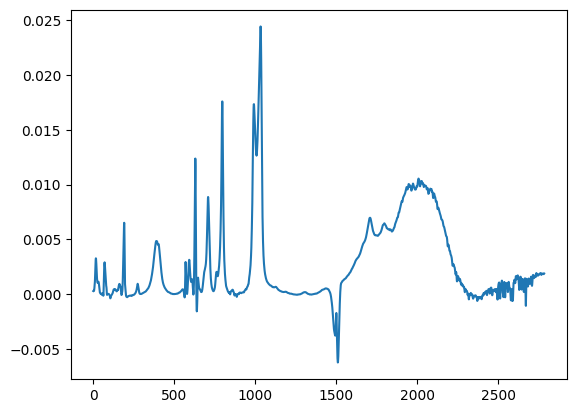

In [124]:
plt.plot(veb_pb_dict["Malonic Acid"][12]["MAP"])

In [3]:
def veb_pb_elbo(y, tau, nu, d, f, mu, W, V):
    p, c = y.shape[0], W.shape[1]

    theta = y - mu - W @ nu - V @ f
    delta = np.sqrt(np.sum((W * d) ** 2, axis=1))
    z = theta / delta

    g = theta * norm_cdf(z) + delta * norm_pdf(z) + (tau - 1) * theta
    sigma_hat = np.mean(g)

    return (
        p * np.log(tau)
        + p * np.log(1 - tau)
        - p * np.log(sigma_hat)
        - 0.5 * np.sum(nu**2)
        - 0.5 * np.sum(d**2)
        + np.sum(np.log(d))
        + (c / 2 - p)
    )
    
def veb_pb_jac_elbo(y, tau, nu, d, f, mu, W, V):
    p = y.shape[0]

    theta = y - mu - W @ nu - V @ f
    delta = np.sqrt(np.sum((W * d) ** 2, axis=1))
    z = theta / delta

    Phi = norm_cdf(z)
    phi = norm_pdf(z)
    g = theta * Phi + delta * phi + (tau - 1) * theta
    sigma_hat = np.mean(g)

    dtau = p / tau - p / (1 - tau) - np.sum(theta) / sigma_hat
    dnu = -(W.T @ ((1 - tau) - Phi)) / sigma_hat - nu
    dd = 1 / d - d - ((W**2).T @ (phi / delta)) * (d / sigma_hat)
    df = -(V.T @ ((1 - tau) - Phi)) / sigma_hat 
    
    return dtau, dnu, dd, df

def veb_pb_optim_prep(
    y, tau_init, nu_init, d_init, f_init, mu, W, V, tau_min=1e-5, tau_max=0.25, sd_min=1e-10
):
    c = nu_init.shape[0]
    nu_slice = slice(1, 1 + c)
    d_slice = slice(1 + c, 1 + 2*c)
    f_slice = slice(1 + 2*c, None)

    def fun(pars):
        return -veb_pb_elbo(y, pars[0], pars[nu_slice], pars[d_slice], pars[f_slice], mu, W, V)

    def jac_fun(pars):
        dtau, dnu, dd, df = veb_pb_jac_elbo(
            y, pars[0], pars[nu_slice], pars[d_slice], pars[f_slice], mu, W, V
        )
        return -np.concatenate(([dtau], dnu, dd, df))

    init = np.concatenate(([tau_init], nu_init, d_init, f_init))
    bnds = ((tau_min, tau_max),) + ((-np.inf, np.inf),) * c + ((sd_min, np.inf),) * c + ((0, np.inf),) * V.shape[1]

    return fun, jac_fun, init, bnds

def pb_sigma_hat(y, tau, nu, d, f, mu, W, V):
    theta = y - mu - W @ nu - V @ f
    delta = np.sqrt(np.sum((W * d) ** 2, axis=1))
    z = theta / delta

    Phi = norm_cdf(z)
    phi = norm_pdf(z)
    g = theta * Phi + delta * phi + (tau - 1) * theta
    sigma_hat = np.mean(g)

    return sigma_hat

def pb_map(y, mu, W, V, tau, sigma, mit=None, verbose=False):
    x = cp.Variable(W.shape[1])
    f = cp.Variable(V.shape[1],nonneg=True)
    prob = cp.Problem(
        cp.Minimize(
            cp.sum(0.5 * cp.abs(y - mu - W @ x - V @ f) + (tau - 0.5) * (y - mu - W @ x - V @ f ))
            + 0.5 * sigma * cp.sum_squares(x)
        )
    )

    prob.solve(solver=cp.CLARABEL, verbose=verbose)

    return mu + W @ x.value, V@f.value ,x.value , f.value

def uncentered_correlation(f, fhat):
    return np.dot(f, fhat) / (np.linalg.norm(f) * np.linalg.norm(fhat))    

def emsc(y,mu,W,V,verbose=False):
    x = cp.Variable(W.shape[1])
    f = cp.Variable(V.shape[1],nonneg=True)
    
    prob = cp.Problem(
        cp.Minimize(
            cp.sum_squares(y - mu - W @ x - V @ f)
        )
    )

    prob.solve(solver=cp.CLARABEL, verbose=verbose)

    return mu + W @ x.value, V@f.value ,x.value , f.value

In [71]:
comp_dict = {}
for comp in ref_dict:
    comp_dict[comp] = {"Y":np.array(raw_spectra_dict[comp]["raw"])}
    v = ref_dict[comp][:,1]
    v = np.interp(wn, ref_dict[comp][:,0], ref_dict[comp][:,1]).reshape(-1, 1)
    
    if comp == "Ammonium sulfate":
        f = np.array(spectra_responses[comp]["AS"])
    else:
        f = np.array(spectra_responses[comp]["OC"])
        
    comp_dict[comp]["f"] = f
    comp_dict[comp]["v"] = v

In [74]:
for comp in comp_dict:
    fhats = []
    Y = comp_dict[comp]["Y"]
    v = comp_dict[comp]["v"]
    f = comp_dict[comp]["f"]
    for i in range(len(Y)):
        y = Y[i,:]
        _, _, _, fhat = emsc(y,mu,W,v)
        fhats.append(fhat)
    fhats = np.array(fhats)
    comp_dict[comp]["fhat_emsc"] = fhats
    print(comp,uncentered_correlation(f, fhats)[0])


12-Tricosanone 0.9997298583974681
Ammonium sulfate 0.9983293610594322
Malonic Acid 0.9897278503645184
Suberic Acid 0.999424422861754
D-Glucose 0.9994119571467107
fructose 0.9995865034319018
levoglucosan 0.9985414108082257


In [78]:
for comp in comp_dict:
    fhats = []
    Y = comp_dict[comp]["Y"]
    v = comp_dict[comp]["v"]
    f = comp_dict[comp]["f"]
    
    for i in range(len(Y)):
        y = Y[i,:]
        fun, jac_fun, init, bnds = veb_pb_optim_prep(y,0.5,np.zeros(W.shape[1]),np.ones(W.shape[1]),np.zeros(v.shape[1]), mu, W, v, tau_min=0.5, tau_max=0.5, sd_min=1e-10)
        opt = minimize(
                fun,
                init,
                method="L-BFGS-B",
                jac=jac_fun,
                bounds=bnds,
                options={"maxiter": 10000},
            )
        tau, nu, t0 = opt.x[0], opt.x[1 : (1 + W.shape[1])], W.shape[1] + 1
        d = opt.x[t0:(t0 + W.shape[1])]
        t0 += W.shape[1]
        fhat = opt.x[t0:]        
        
        sigma_hat = pb_sigma_hat(y, tau, nu, d, fhat, mu, W, v)
        z, _, _, fhat = pb_map(y, mu, W, v, tau, sigma_hat, mit=None, verbose=False)
        fhats.append(fhat)
        
    fhats = np.array(fhats)
    comp_dict[comp]["fhat_emsc"] = fhats
    
    print(comp,uncentered_correlation(f, fhats)[0])

12-Tricosanone 0.9982281684953114
Ammonium sulfate 0.9991103313752705
Malonic Acid 0.9805335167563919
Suberic Acid 0.9992517175748915
D-Glucose 0.9983783207668185
fructose 0.9986375099586846
levoglucosan 0.9952445240773763


In [4]:
Y = []
F = []
V = []
for comp in ref_dict:
    Y.append(np.array(raw_spectra_dict[comp]["raw"]))
    v = ref_dict[comp][:,1]
    v = np.interp(wn, ref_dict[comp][:,0], ref_dict[comp][:,1]).reshape(-1, 1)
    V.append(v)
Y = np.concatenate(Y)
V = np.hstack(V)
F = np.zeros((Y.shape[0], len(ref_dict)))

col_idx = 0
row_idx = 0
for comp in ref_dict: 
    if comp == "Ammonium sulfate":
        f = np.array(spectra_responses[comp]["AS"])
    else:
        f = np.array(spectra_responses[comp]["OC"])
    F[row_idx:(row_idx + f.shape[0]), col_idx] = f
    row_idx += f.shape[0]
    col_idx += 1
    
Z = blanks_dict["2011"]
wn = Z.columns
Z = np.array(Z)

_ , chat_ose, _ = loo_pca(Z, detrend=True)
mu, _, _, W = pca(Z,detrend=True)
W = W[:,:chat_ose]

In [5]:
fhat = []
zhat = []
taus = []

for i in tqdm(range(Y.shape[0])):
    y = Y[i,:]
    fun, jac_fun, init, bnds = veb_pb_optim_prep(y,0.5,np.zeros(W.shape[1]),np.ones(W.shape[1]),np.zeros(V.shape[1]), mu, W, V, tau_min=0.5, tau_max=0.5, sd_min=1e-10)
    opt = minimize(
                fun,
                init,
                method="L-BFGS-B",
                jac=jac_fun,
                bounds=bnds,
                options={"maxiter": 10000},
            )
    tau, nu, t0 = opt.x[0], opt.x[1 : (1 + W.shape[1])], W.shape[1] + 1
    d = opt.x[t0:(t0 + W.shape[1])]
    t0 += W.shape[1]
    f = opt.x[t0:]
    
    sigma_hat = pb_sigma_hat(y, tau, nu, d, f, mu, W, V)
    z, _, _, f = pb_map(y, mu, W, V, tau, sigma_hat, mit=None, verbose=False)
    
    fhat.append(f)
    zhat.append(z)
    taus.append(tau)

fhat = np.array(fhat)
zhat = np.array(zhat)
taus = np.array(taus)


100%|██████████| 189/189 [34:28<00:00, 10.95s/it]


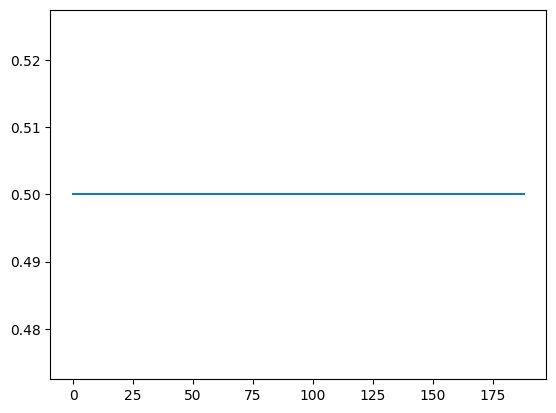

In [6]:
taus = np.array(taus)
plt.plot(taus)

In [12]:
scores1 = []
fhat_all1 = []
f_all = []

for i in range(F.shape[1]):
    scores1.append(uncentered_correlation(F[:,i], fhat[:,i]))
    fhat_all1.append(fhat[:,i])
    f_all.append(F[:,i])

fhat_all1 = np.concatenate(fhat_all1)
f_all = np.concatenate(f_all)

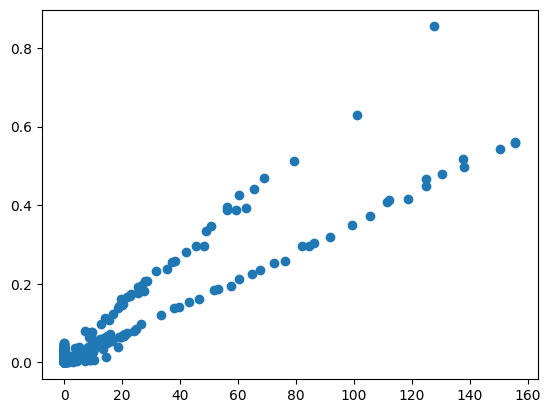

In [13]:
plt.scatter(f_all, fhat_all1)

In [8]:
fhat = []
zhat = []

for i in tqdm(range(Y.shape[0])):
    y = Y[i,:]
    z, _, _, f = emsc(y,mu,W,V)
    fhat.append(f)
    zhat.append(z)

fhat = np.array(fhat)
zhat = np.array(zhat)


100%|██████████| 189/189 [00:28<00:00,  6.65it/s]


In [9]:
scores2 = []
for i in range(F.shape[1]):
    scores2.append(uncentered_correlation(F[:,i], fhat[:,i]))

C:\Users\franc\AppData\Local\Temp\ipykernel_15848\492196537.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([scores1,scores2], labels=["VEB-PB","EMSC"])


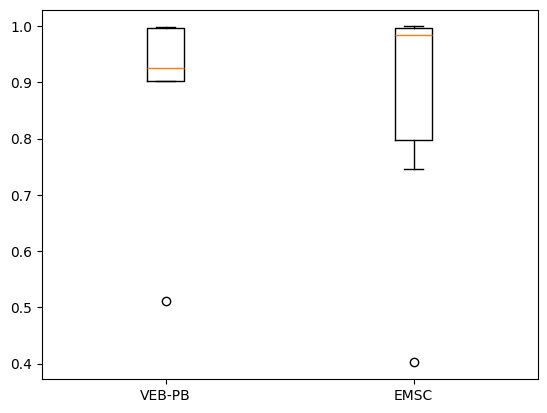

In [10]:
plt.boxplot([scores1,scores2], labels=["VEB-PB","EMSC"])
plt.show()

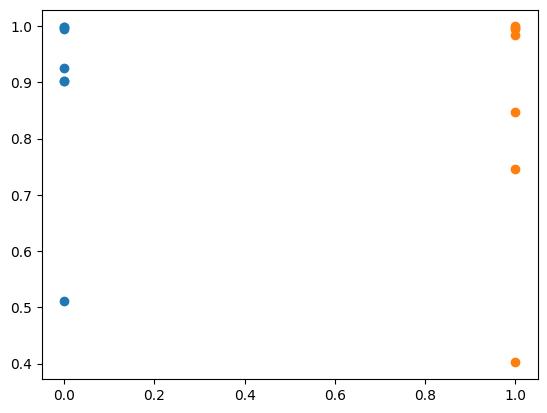

In [11]:
plt.scatter(np.repeat(0, len(scores1)), scores1)
plt.scatter(np.repeat(1, len(scores2)), scores2)

In [52]:
print(np.mean(scores1), np.mean(scores2))
print(np.median(scores1), np.median(scores2))

0.8890425299286616 0.8529923943239802
0.9320201213783421 0.984797558873632


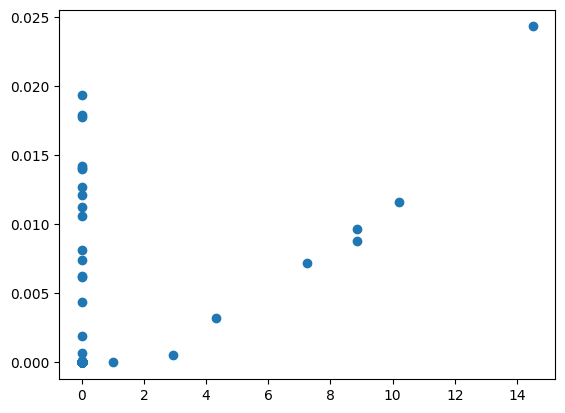

In [13]:
plt.scatter(F[:,4], fhat[:,4])

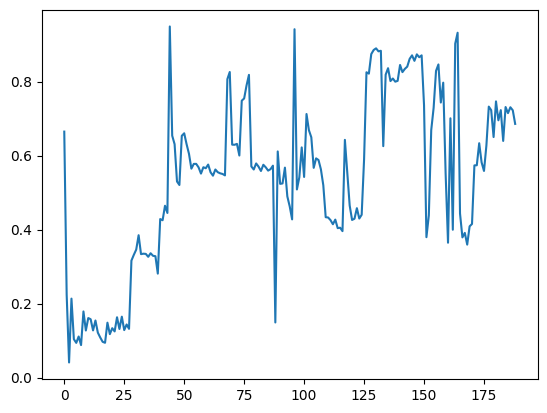

In [68]:
plt.plot(taus)

In [177]:
uncentered_correlation(f, fhat[:,0])

np.float64(0.9990132898151657)

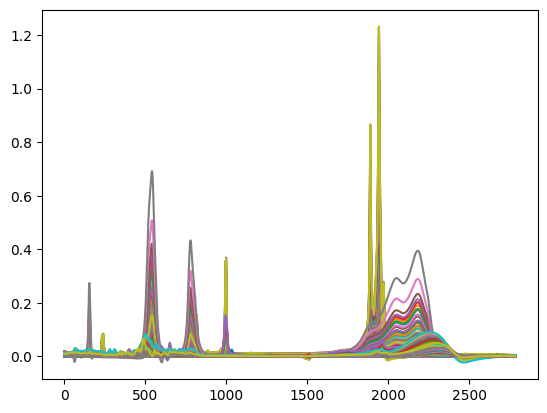

In [14]:
for i in range(Y.shape[0]):
    plt.plot((Y[i,:]-zhat[i]) )

(array([-0.06310006, -0.0630717 , -0.06304509, ...,  0.40313813,
         0.40344277,  0.40376456], shape=(2785,)),
 array([4.50725186e-05, 4.60435227e-05, 4.70145447e-05, ...,
        3.86619089e-05, 3.86645212e-05, 3.86665891e-05], shape=(2785,)),
 array([-1.17027576e+00, -2.04263198e+00, -1.59821949e-01, -3.28478030e+00,
         1.57250641e+00,  3.62541598e-01,  9.48249573e-01, -4.45251172e+00,
         9.81186787e+00, -3.60771793e+00, -2.01685029e-02, -1.01969826e-01,
         8.54898425e-01, -1.73788788e+00, -2.79211433e+00, -7.62474654e+00,
         4.94222159e+00,  2.47695341e+00,  4.91206876e+00, -1.04066377e+01,
        -8.09697918e+00,  6.68949365e+00,  3.69528542e+00, -4.13458631e+00,
        -7.33585639e-01, -2.37148616e+01,  6.03286747e+00, -1.29310386e+01,
        -2.63626734e+01, -1.33429072e+01,  1.98813899e+00, -9.60366529e+00,
         1.33425108e+01,  1.86639990e+01, -1.69832902e+01, -1.66588088e+01,
         1.34905589e+01, -9.07392424e+00,  9.71505842e+00, -1.6092

In [129]:
 uncentered_correlation(f, fhat)

array([0.97674174])

In [122]:
f = np.array(spectra_responses[comp]["OC"])

In [123]:
f

array([0.98084333, 0.68659033, 0.98084333, 1.37318066, 1.27509633,
       1.56934932, 1.47126499, 2.15785532, 0.68659033, 1.27509633,
       0.88275899, 1.27509633, 1.96168665])

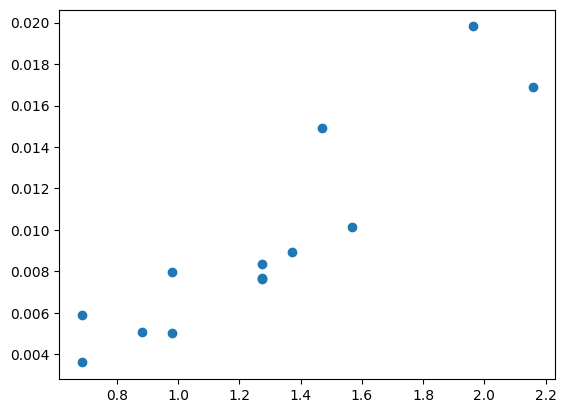

In [124]:
plt.scatter(f,fhat)

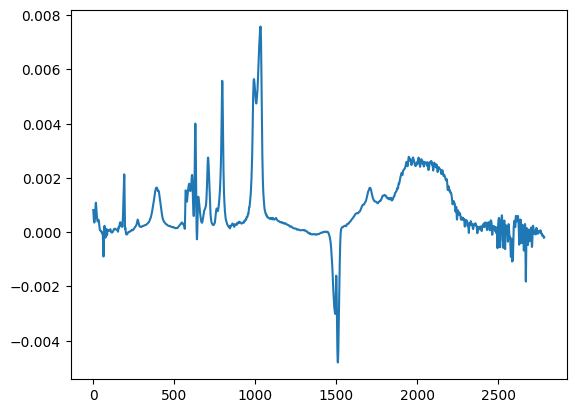

In [114]:
plt.plot(y-z)

In [115]:
tau

np.float64(0.6878088272438144)

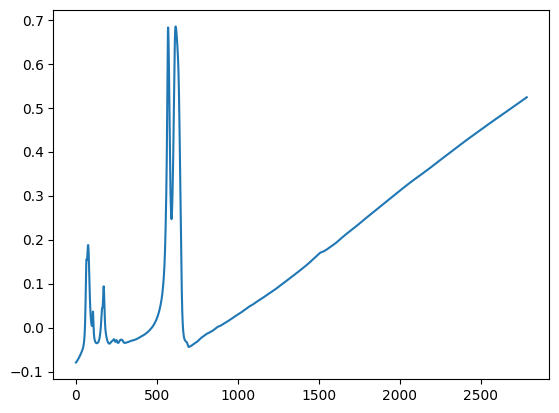

In [107]:
plt.plot(z)

In [ ]:


V = np.hstack([CO2[:,[1]], H2O[:,[1]]])

In [222]:
y = Y[5,:]
tau = 0.1
nu = np.random.normal(size=W.shape[1]) 
d = np.ones(W.shape[1])
f = np.random.normal(size=V.shape[1]) 

In [223]:
veb_pb_elbo(y, tau, nu, d, f, mu, W, V)

np.float64(2844.67389544865)

In [231]:
h = 1e-8
(veb_pb_elbo(y, tau+h, nu, d, f, mu, W, V) - veb_pb_elbo(y, tau-h, nu, d, f, mu, W, V)) / (2 * h), veb_pb_jac_elbo(y, tau, nu, d, f, mu, W, V)[0]

(np.float64(-1638.925004954217), np.float64(-1638.9251376268112))

In [232]:
h = 1e-8
for i in range(W.shape[1]):
    nuh = nu.copy()
    nuh[i] += h
    print((veb_pb_elbo(y, tau, nuh, d, f, mu, W, V) - veb_pb_elbo(y, tau, nu, d, f, mu, W, V)) / h, veb_pb_jac_elbo(y, tau, nu, d, f, mu, W, V)[1][i])

886.9438715919387 886.9439003778539
-19.860999600496143 -19.860934148532
6.265963747864589 6.265961127957582
-2.8648173611145467 -2.8648620086603205
-8.793631423031911 -8.793602662163282
-5.555921234190464 -5.556044970057919
13.960561773274094 13.960517688751505
1.0449184628669173 1.0450080963346213
-1.0639269021339715 -1.0639348692929433
-0.5205947672948241 -0.5206091736644362
-2.375054464209825 -2.375035666712647
-2.082470018649474 -2.0824222541260493
-1.6774720279499888 -1.6776068414947245
-1.5140358300413936 -1.5138961207291857
-1.3126737030688673 -1.3126547081573692
1.1680640454869717 1.168087115553195
0.9615177987143397 0.9615512490392175
-2.7361238608136773 -2.736076965319379
0.6164555088616908 0.6162119298637426
-1.5024852473288774 -1.5023599027259853
0.02964952727779746 0.02958179793908052
-0.41909515857696533 -0.4191952433652828
-1.5975274436641484 -1.597631502060878
0.09649738785810769 0.09644866991458056
-0.39208316593430936 -0.3920842530880365
1.1129486665595323 1.11281757

In [233]:
h = 1e-6
for i in range(W.shape[1]):
    dh = d.copy()
    dh[i] += h
    print((veb_pb_elbo(y, tau, nu, dh, f, mu, W, V) - veb_pb_elbo(y, tau, nu, d, f, mu, W, V)) / h, veb_pb_jac_elbo(y, tau, nu, d, f, mu, W, V)[2][i])

-216.64159885403933 -216.64109497790704
-3.837551957985852 -3.837548817149828
-3.3641163099673577 -3.364113597424869
-0.5107949618832208 -0.5107940921814353
-1.4847310012555681 -1.4847285702792408
-0.49728168960427865 -0.49727908082682826
-1.2924874681630172 -1.2924838562680083
-0.03504192136460915 -0.035040558681840486
-0.031725903681945056 -0.03172440349784913
-0.011347765394020826 -0.01134626787281176
-0.003940840542782098 -0.003940065310414627
-0.006360096449498087 -0.0063600302198729315
-0.006598384061362594 -0.0065960115486279535
-0.0021600499167107046 -0.002158402144345399
-0.000924956111703068 -0.0009252028682317571
-0.0008958522812463343 -0.0008942064529216296
-0.0005047695594839752 -0.0005053505572180128
-0.0005029505700804293 -0.0005017388511623988
-0.0008794813766144216 -0.000877904946115461
-0.0006775735528208315 -0.0006778736858696385
-0.00028830982046201825 -0.0002867966077195925
-0.0006775735528208315 -0.0006777758158798686
-7.185008144006133e-05 -7.181827906805117e-05


In [235]:
h = 1e-8
for i in range(V.shape[1]):
    fh = f.copy()
    fh[i] += h
    print((veb_pb_elbo(y, tau, nu, d, fh, mu, W, V) - veb_pb_elbo(y, tau, nu, d, f, mu, W, V)) / h, veb_pb_jac_elbo(y, tau, nu, d, fh, mu, W, V)[3][i])

281.3510945998132 281.35120885968337
-4.498360794968903 -4.498401454115123


In [261]:
Y = np.array(raw_spectra_dict["Malonic Acid"]["raw"])

In [262]:
_ , chat_ose, _ = loo_pca(Z, detrend=True)
mu, _, _, W = pca(Z,detrend=True)
W = W[:,:chat_ose]
V = np.hstack([CO2[:,[1]], H2O[:,[1]]])

In [306]:
y = Y[3,:]
tau = 0.1
nu = np.zeros(W.shape[1])
d = np.ones(W.shape[1])
f = np.zeros(V.shape[1])

In [307]:
fun, jac_fun, init, bnds = veb_pb_optim_prep(
    y, tau, nu, d, f, mu, W, V, tau_min=1e-5, tau_max=0.25, sd_min=1e-10
)

In [308]:
opt = minimize(
                fun,
                init,
                method="L-BFGS-B",
                jac=jac_fun,
                bounds=bnds,
                options={"maxiter": 20000},
            )

In [ ]:
tau, nu, t0 = opt.x[0], opt.x[1 : (1 + W.shape[1])], W.shape[1] + 1
d = opt.x[t0:(t0 + W.shape[1])]
t0 += W.shape[1]
f = opt.x[t0:]
sigma_hat = pb_sigma_hat(y, tau, nu, d, f, mu, W, V)
z, v, _,_ = pb_map(y, mu, W, V, tau, sigma_hat, mit=None, verbose=False)

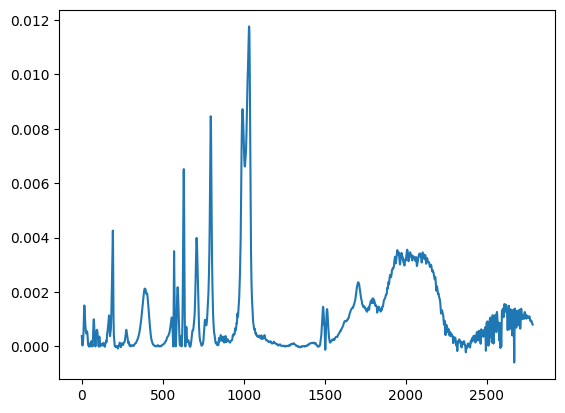

In [311]:
plt.plot(y-z-v)

In [351]:
comp = "fructose"

_ , chat_ose, _ = loo_pca(Z, detrend=True)
mu, _, _, W = pca(Z,detrend=True)
W = W[:,:chat_ose]

V = np.hstack([CO2[:,[1]]])

In [352]:
corrections = []

In [353]:
Y = np.array(raw_spectra_dict[comp]["raw"])
for i in tqdm(range(Y.shape[0])):
    y = Y[i,:]
    nu = np.zeros(W.shape[1])
    f = np.zeros(V.shape[1])
    d = np.ones(W.shape[1])
    tau = 0.1
    
    fun, jac_fun, init, bnds = veb_pb_optim_prep(
        y, tau, nu, d, f, mu, W, V, tau_min=1e-5, tau_max=0.25, sd_min=1e-10
    )    
    
    opt = minimize(
                fun,
                init,
                method="L-BFGS-B",
                jac=jac_fun,
                bounds=bnds,
                options={"maxiter": 10000},
            )
    
    tau, nu, t0 = opt.x[0], opt.x[1 : (1 + W.shape[1])], W.shape[1] + 1
    d = opt.x[t0:(t0 + W.shape[1])] 
    t0 += W.shape[1]
    f = opt.x[t0:]
    sigma_hat = pb_sigma_hat(y, tau, nu, d, f, mu, W, V)
    
    z, z1, _,_ = pb_map(y, mu, W, V, tau, sigma_hat, mit=None, verbose=False)
    
    corrections.append(y - z - z1)

100%|██████████| 17/17 [05:35<00:00, 19.75s/it]


In [354]:
corrections = np.array(corrections)
ref_profile = ref_dict[comp][:, 1]
ref_wn = ref_dict[comp][:, 0]
interpolated_corrections = [np.interp(ref_wn, wn, c) for c in corrections]
corrs = np.array(
            [np.corrcoef(ref_profile, c)[0, 1] for c in interpolated_corrections]
        )
print(corrs)
print(np.mean(corrs))

[0.89229918 0.92110388 0.91912127 0.90183389 0.90532206 0.90113265
 0.89077089 0.85699438 0.86954723 0.85101602 0.84323329 0.79012139
 0.79443563 0.78692351 0.78250592 0.76951203 0.7448301 ]
0.8482766648054404


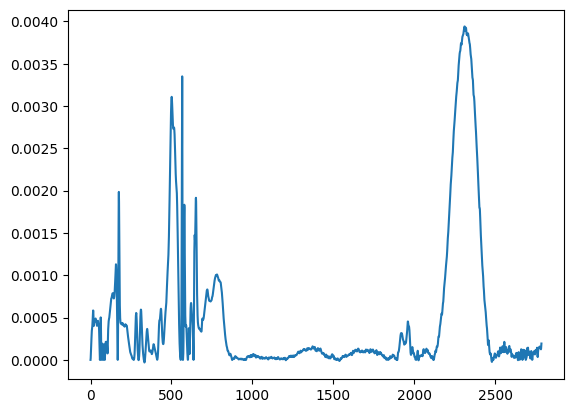

In [356]:
plt.plot(corrections[0])

In [187]:
corrections = np.array(corrections)
ref_profile = ref_dict[comp][:, 1]
ref_wn = ref_dict[comp][:, 0]
interpolated_corrections = [np.interp(ref_wn, wn, c) for c in corrections]
corrs = np.array(
            [np.corrcoef(ref_profile, c)[0, 1] for c in interpolated_corrections]
        )
print(corrs)
print(np.mean(corrs))

[0.73940675 0.68960858 0.6767941  0.68523208 0.71181009 0.68922839
 0.75275743 0.7387277  0.63451656 0.66163267 0.65101381 0.67905562
 0.71820882]
0.694460969445722


In [188]:
corrections

array([[ 1.37141622e-03,  1.18164317e-03,  7.54518235e-04, ...,
         4.60358672e-05,  3.24910208e-05, -1.64090204e-05],
       [ 6.16106947e-05,  5.46269363e-05,  2.44533647e-05, ...,
        -3.91421464e-04, -3.69097700e-04, -3.30816740e-04],
       [-1.52633125e-04, -9.57807454e-05, -6.77967404e-12, ...,
        -4.52731388e-04, -5.83539702e-04, -7.16291655e-04],
       ...,
       [-4.90607214e-05,  2.79594276e-05,  6.49107061e-05, ...,
        -4.00837650e-04, -4.48611679e-04, -4.77728884e-04],
       [-5.42513700e-05,  1.42963419e-12,  6.48939791e-05, ...,
        -5.96816651e-04, -5.84365602e-04, -5.64611824e-04],
       [ 2.38594795e-04,  1.48254312e-04,  6.48706836e-05, ...,
        -7.66493194e-04, -6.68824674e-04, -5.59718730e-04]],
      shape=(13, 2785))

In [590]:
def veb_pb_elbo(y, tau, nu1, nu2, d1, d2, mu, W1, W2):
    p, c1 = y.shape[0], W1.shape[1] 
    theta = y - mu - W1 @ nu1- W2 @ nu2
    delta = np.sqrt(np.sum((W1 * d1) ** 2, axis=1) + np.sum((W2 * d2) ** 2, axis=1))
    z = theta / delta
    g = theta * norm_cdf(z) + delta * norm_pdf(z) + (tau - 1) * theta
    sigma_hat = np.mean(g)
    gamma = np.sqrt(d2**2 + nu2**2)
    
    return (c1/2 - p) + p * np.log(tau) + p * np.log(1 - tau) - p * np.log(sigma_hat) - 0.5 * np.sum(nu1**2) - 0.5 * np.sum(d1**2) + np.sum(np.log(d1) + np.log(d2)) - 0.5*np.sum(np.log(gamma*2))


In [591]:
Z = blanks_dict["2011"]
wn = Z.columns
Z = np.array(Z)

In [592]:
_ , chat_ose, _ = loo_pca(Z, detrend=True)
mu, _, _, W1 = pca(Z,detrend=True)
W1 = W1[:,:chat_ose]
W2 = CO2[:,[1]]

In [593]:
tau = 0.1 
nu1 = np.zeros(W1.shape[1]) + 1
nu2 = np.zeros(W2.shape[1]) + 1
d1 = np.ones(W1.shape[1]) + 1
d2 = np.ones(W2.shape[1]) + 1

comp = "Malonic Acid"
Y = np.array(raw_spectra_dict[comp]["raw"])
y = Y[3,:]

In [594]:
d2

array([2.])

In [595]:
veb_pb_elbo(y, tau, nu1, nu2, d2, d2, mu, W1, W2)

np.float64(-2305.1521222773285)

In [596]:
def veb_pb_jac_elbo(y, tau, nu1, nu2, d1, d2, mu, W1, W2):
    p = y.shape[0]

    theta = y - mu - W1 @ nu1 - W2 @ nu2
    delta = np.sqrt(np.sum((W1 * d1) ** 2, axis=1) + np.sum((W2 * d2) ** 2, axis=1))
    z = theta / delta

    Phi = norm_cdf(z)
    phi = norm_pdf(z)
    g = theta * Phi + delta * phi + (tau - 1) * theta
    sigma_hat = np.mean(g)
    gamma = np.sqrt(d2**2 + nu2**2)

    dtau = p / tau - p / (1 - tau) - np.sum(theta) / sigma_hat
    dnu1 = -(W1.T @ ((1 - tau) - Phi)) / sigma_hat - nu1 
    dd1 = 1 / d1 - d1 - ((W1**2).T @ (phi / delta)) * (d1 / sigma_hat) 
    dnu2 = -(W2.T @ ((1 - tau) - Phi)) / sigma_hat - nu2 / gamma / gamma
    dd2 = 1 / d2 - d2 /gamma /gamma - ((W2**2).T @ (phi / delta)) * (d2 / sigma_hat) 


    return dtau, dnu1, dnu2, dd1, dd2

In [597]:
h = 1e-8
print((veb_pb_elbo(y, tau + h, nu1, nu2, d1, d2, mu, W1, W2) - veb_pb_elbo(y, tau, nu1, nu2, d1, d2, mu, W1, W2))/h,veb_pb_jac_elbo(y, tau, nu1, nu2, d1, d2, mu, W1, W2)[0])

27157.176828040974 27157.177912697185


In [598]:
h = 1e-8
for i in range(W1.shape[1]):
    nu1_h = nu1.copy()
    nu1_h[i] += h
    print((veb_pb_elbo(y, tau, nu1_h, nu2, d1, d2, mu, W1, W2) - veb_pb_elbo(y, tau, nu1, nu2, d1, d2, mu, W1, W2))/h,veb_pb_jac_elbo(y, tau, nu1, nu2, d1, d2, mu, W1, W2)[1][i])

-953.3256161375903 -953.3257023783003
2.054275682894513 2.054192808458076
-25.87066774140112 -25.870763181359987
2.992510417243466 2.9924062819667623
-3.736113285413012 -3.7362988294889887
-3.930927050532773 -3.9310313876573795
3.546301741153002 3.5462620615729845
-0.8618371794000268 -0.8618755461832956
-1.0453732102178037 -1.0454413889059326
-1.1820702638942748 -1.1820639191291056
-0.9553332347422838 -0.9554146991397754
-1.0495568858459592 -1.0496927525595776
-0.9611540008336306 -0.9611522753805675
-0.9875293471850455 -0.987602302384832
-0.9815266821533442 -0.9816259512849651
-1.0199073585681617 -1.0199802267478553
-1.0055373422801495 -1.005594267928278
-1.005082594929263 -1.0051605239543908
-0.9878931450657547 -0.9879593963226189
-0.9979885362554342 -0.9981004751982115
-1.000444171950221 -1.0004570812532523
-1.01190380519256 -1.0120299535056259
-0.9999894245993346 -1.000091658488259
-0.9958057489711791 -0.9958159087923955
-1.0014446161221713 -1.0015773234246512
-0.9958057489711791 -0

In [599]:
h = 1e-8
for i in range(W2.shape[1]):
    nu2_h = nu2.copy()
    nu2_h[i] += h
    print((veb_pb_elbo(y, tau, nu1, nu2_h, d1, d2, mu, W1, W2) - veb_pb_elbo(y, tau, nu1, nu2, d1, d2, mu, W1, W2))/h,veb_pb_jac_elbo(y, tau, nu1, nu2, d1, d2, mu, W1, W2)[2][i])

-272.0460088312393 -272.1460785370635


In [600]:
h = 1e-8
for i in range(W1.shape[1]):
    d1_h = d1.copy()
    d1_h[i] += h
    print((veb_pb_elbo(y, tau, nu1, nu2, d1_h, d2, mu, W1, W2) - veb_pb_elbo(y, tau, nu1, nu2, d1, d2, mu, W1, W2))/h,veb_pb_jac_elbo(y, tau, nu1, nu2, d1, d2, mu, W1, W2)[3][i])

-471.34130909398664 -471.34137667895266
-3.42911334882956 -3.4292658628952086
-3.5026005207328126 -3.5026741497758374
-1.7311776900896803 -1.7313011513378913
-1.7634647520026192 -1.763447107722295
-1.6198555385926738 -1.6199216909835397
-1.8414993974147364 -1.8415102745432064
-1.5101704775588587 -1.510134104194775
-1.5103523764992133 -1.5103851158094046
-1.5086243365658447 -1.5086894245847755
-1.503440216765739 -1.5035351134283836
-1.5035311662359163 -1.5036995718276065
-1.5017121768323705 -1.5017876633892175
-1.5008936316007748 -1.5009544374086305
-1.5004388842498884 -1.5004608572568248
-1.5002569853095338 -1.5003825908018757
-1.5000750863691792 -1.5002240996026317
-1.5000750863691792 -1.5002111985604183
-1.5000750863691792 -1.5002402357174183
-1.5000750863691792 -1.500160924560581
-1.499984136899002 -1.5000801414860503
-1.5000750863691792 -1.5001524835032392
-1.499984136899002 -1.5000358639518765
-1.499984136899002 -1.5000278042457396
-1.499984136899002 -1.5000516317670878
-1.4999841

In [601]:
h = 1e-10
for i in range(W2.shape[1]):
    d2_h = d2.copy()
    d2_h[i] += h
    print((veb_pb_elbo(y, tau, nu1, nu2, d1, d2_h, mu, W1, W2) - veb_pb_elbo(y, tau, nu1, nu2, d1, d2, mu, W1, W2))/h,veb_pb_jac_elbo(y, tau, nu1, nu2, d1, d2, mu, W1, W2)[4][i])

-123.51847544778138 -146.72328132961883


In [524]:
d2_h

array([2.])

In [76]:
def veb_pb_jac_elbo(y, tau, nu, d, mu, W):
    p = y.shape[0]

    theta = y - mu - W @ nu
    delta = np.sqrt(np.sum((W * d) ** 2, axis=1))
    z = theta / delta

    Phi = norm_cdf(z)
    phi = norm_pdf(z)
    g = theta * Phi + delta * phi + (tau - 1) * theta
    sigma_hat = np.mean(g)
    gamma = d**2 + nu**2

    dtau = p / tau - p / (1 - tau) - np.sum(theta) / sigma_hat
    dnu = -(W.T @ ((1 - tau) - Phi)) / sigma_hat - nu / gamma
    dd = 1 / d - d/gamma - ((W**2).T @ (phi / delta)) * (d / sigma_hat)

    return dtau, dnu, dd

def pb_sigma_hat(y, tau, nu, d, mu, W):
    theta = y - mu - W @ nu
    delta = np.sqrt(np.sum((W * d) ** 2, axis=1))
    z = theta / delta

    Phi = norm_cdf(z)
    phi = norm_pdf(z)
    g = theta * Phi + delta * phi + (tau - 1) * theta
    sigma_hat = np.mean(g)

    return sigma_hat


In [ ]:
_ , chat_ose, _ = loo_pca(Z, detrend=True)
mu, _, _, W = pca(Z,detrend=True)
W = W[:,:chat_ose]
y = Y[5,:]
nu = np.zeros(W.shape[1])
d = np.ones(W.shape[1])
tau = 0.1

In [55]:
veb_pb_elbo(y, tau, nu, d, mu, W)

np.float64(3832.36584218815)

In [56]:
h = 1e-8

print((veb_pb_elbo(y, tau+h, nu, d, mu, W) - veb_pb_elbo(y, tau, nu, d, mu, W) )/ h,veb_pb_jac_elbo(y, tau, nu, d, mu, W)[0])

6396.985190804116 6396.986148466738


In [57]:
h = 1e-8
for i in range(W.shape[1]):
    nu_h = nu.copy()
    nu_h[i] += h
    print((veb_pb_elbo(y, tau, nu_h, d, mu, W) - veb_pb_elbo(y, tau, nu, d, mu, W) )/h,veb_pb_jac_elbo(y, tau, nu_h, d, mu, W)[1][i])

-20.001789380330592 -20.001640476005235
-88.36705092107877 -88.36682303867866
-16.896774468477815 -16.89656342757283
-0.4687535692937672 -0.46863109670275943
-15.005389286670834 -15.005414925164624
-17.41427695378661 -17.41402371096388
31.861418392509222 31.86152972066929
5.680340109393001 5.680524709927776
0.914405973162502 0.9147091157400989
0.6784830475226045 0.6784706180948458
-1.297667040489614 -1.297633657888455
0.1355147105641663 0.1356614450496796
1.1728843674063683 1.173050710713222
0.38089638110250235 0.3811351460723971
-0.2772139851003885 -0.27722357891341043
0.13587850844487548 0.13594854398641693
0.008913048077374697 0.008966823482894258
-0.046202330850064754 -0.04601514443263185
0.1609805622138083 0.16121331488929627
-0.0012732925824820995 -0.0011775449837302305
-0.014551915228366852 -0.01437282937799082
-0.2104570739902556 -0.21038593555451324
-0.07130438461899757 -0.07118822038726025
0.06093614501878619 0.061086275625181506
0.16443664208054543 0.16469775394192518
0.0138

In [ ]:
h = 1e-5
d_h = d.copy()
d_h[0] += h

In [60]:

for i in range(W.shape[1]):
    d_h = d.copy()
    d_h[i] += h
    print((veb_pb_elbo(y, tau, nu, d_h, mu, W) - veb_pb_elbo(y, tau, nu, d, mu, W) )/h,veb_pb_jac_elbo(y, tau, nu, d, mu, W)[2][i])

-2161.1622785712825 -2161.153517123962
-18.461615945852827 -18.461526412211924
-11.040899698855354 -11.04084415239985
-2.6821167921298184 -2.682103417293447
-3.549723624018952 -3.5497060879359084
-1.3208426025812514 -1.3208360011661757
-1.6042155039031056 -1.6042072632221884
-0.04383146006148308 -0.04383111884261082
-0.06712798494845629 -0.06712741371681145
-0.034673576010391116 -0.03467339462366229
-0.018992795958183706 -0.01899279736626388
-0.01678472472121939 -0.01678439011976935
-0.00804921000963077 -0.008049181972277553
-0.00610161805525422 -0.006101538885515224
-0.0023734173737466335 -0.0023734066408147713
-0.002423621481284499 -0.0024235934479711384
-0.0016552803572267292 -0.0016550597934738911
-0.0011423253454267979 -0.0011421437706428522
-0.0018764694686979053 -0.0018762437171024819
-0.001156331563834101 -0.0011561842429712718
-0.000641375663690269 -0.0006412081008075329
-0.0007403286872431635 -0.0007401679079779825
-0.0003428795025683939 -0.00034280368074959214
-0.00022355379

In [61]:
def veb_pb_optim_prep(
    y, tau_init, nu_init, d_init, mu, W, tau_min=1e-5, tau_max=0.25, sd_min=1e-10
):
    c = nu_init.shape[0]
    nu_slice = slice(1, 1 + c)
    d_slice = slice(1 + c, None)

    def fun(pars):
        return -veb_pb_elbo(y, pars[0], pars[nu_slice], pars[d_slice], mu, W)

    def jac_fun(pars):
        dtau, dnu, dd = veb_pb_jac_elbo(
            y, pars[0], pars[nu_slice], pars[d_slice], mu, W
        )
        return -np.concatenate(([dtau], dnu, dd))

    init = np.concatenate(([tau_init], nu_init, d_init))
    bnds = ((tau_min, tau_max),) + ((-np.inf, np.inf),) * c + ((sd_min, np.inf),) * c

    return fun, jac_fun, init, bnds

In [218]:
all_cors = []
Z = blanks_dict["2011"]
wn = Z.columns
Z = np.array(Z)

In [247]:
_ , chat_ose, _ = loo_pca(Z, detrend=True)
mu, _, _, W = pca(Z,detrend=True)
W = W[:,:chat_ose]
W = np.hstack([W,CO2[:,[1]]])
chat_ose += 1

In [ ]:
comp = "Malonic Acid"
Y = np.array(raw_spectra_dict[comp]["raw"])
y = Y[3,:]

In [256]:
corrections = []
Y = np.array(raw_spectra_dict[comp]["raw"])
for i in tqdm(range(Y.shape[0])):
    y = Y[i,:]
    nu = np.zeros(W.shape[1])
    d = np.ones(W.shape[1])
    tau = 0.1
    
    fun, jac_fun, init, bnds = veb_pb_optim_prep(
                y, tau, nu, d, mu, W
            )

    opt = minimize(
                fun,
                init,
                method="L-BFGS-B",
                jac=jac_fun,
                bounds=bnds,
                options={"maxiter": 20000},
            )

    tau, nu, t0 = opt.x[0], opt.x[1 : (1 + chat_ose)], chat_ose + 1
    d = opt.x[t0:]
    sigma_hat = pb_sigma_hat(y, tau, nu, d, mu, W)
    gamma = d**2 + nu**2
    
    z,_ = pb_map(y, mu, W, tau, sigma_hat, gamma, mit=None, verbose=False)
    
    corrections.append(y - z)

100%|██████████| 13/13 [03:48<00:00, 17.55s/it]


In [257]:
corrections = np.array(corrections)
ref_profile = ref_dict[comp][:, 1]
ref_wn = ref_dict[comp][:, 0]
interpolated_corrections = [np.interp(ref_wn, wn, c) for c in corrections]
corrs = np.array(
            [np.corrcoef(ref_profile, c)[0, 1] for c in interpolated_corrections]
        )

In [258]:
corrs

array([0.76031833, 0.80972564, 0.66490318, 0.69306082, 0.68075918,
       0.64210025, 0.66917197, 0.71588399, 0.64689505, 0.62564958,
       0.60195907, 0.64495433, 0.80675004])

In [259]:
np.mean(corrs)

np.float64(0.6893947263505822)

In [211]:
tau, nu, t0 = opt.x[0], opt.x[1 : (1 + chat_ose)], chat_ose + 1

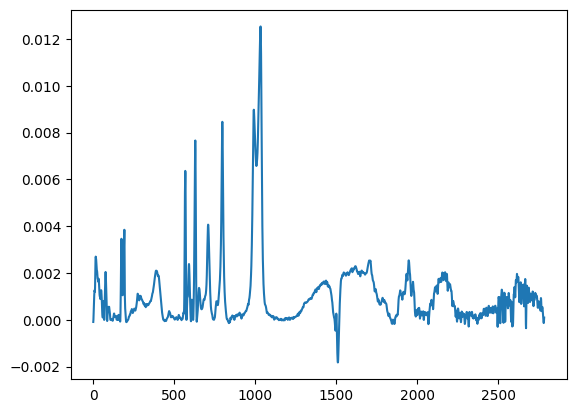

In [261]:
plt.plot(corrections[-2])

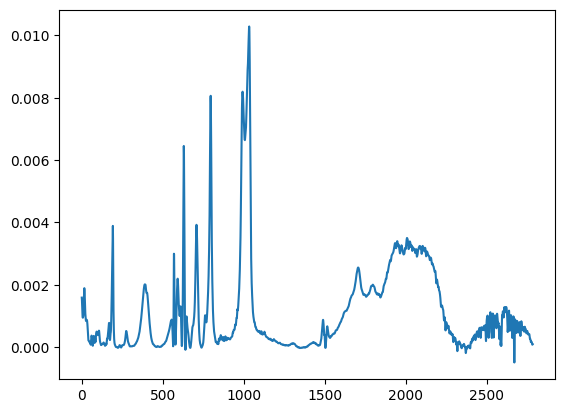

In [237]:
plt.plot(Y[2,:] - W @ nu - mu)

In [1]:
np.mean(corrs)

NameError: name 'np' is not defined

In [206]:
all_cors.append(corrs)

In [171]:
np.mean(corrs)

np.float64(0.9738786472618405)

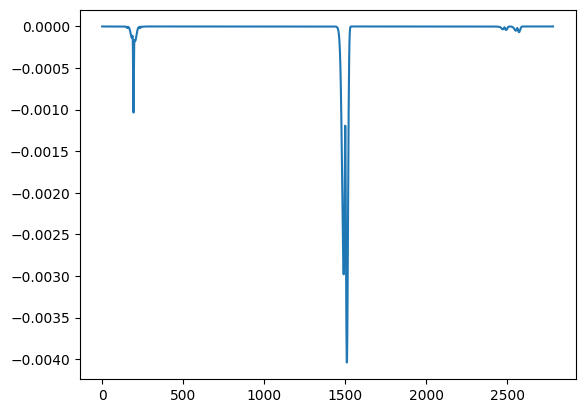

In [246]:
plt.plot(nu[-1]*W[:,-1])

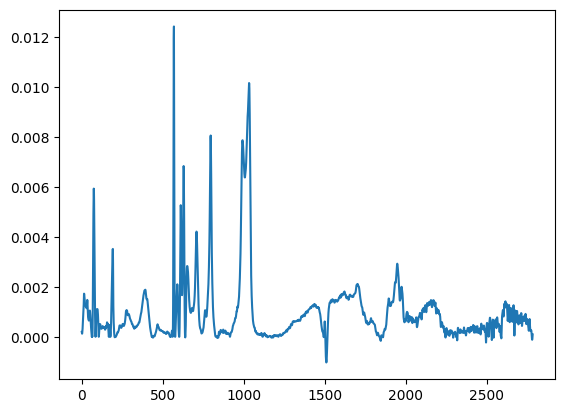

In [242]:
plt.plot(corrections[2,:])

In [172]:
np.mean(all_cors)

np.float64(0.9738786472618405)

In [ ]:
fun, jac_fun, init, bnds = veb_pb_optim_prep(
            y, tau, nu, d, mu, W
        )

opt = minimize(
            fun,
            init,
            method="L-BFGS-B",
            jac=jac_fun,
            bounds=bnds,
            options={"maxiter": 20000},
        )

tau, nu, t0 = opt.x[0], opt.x[1 : (1 + chat_ose)], chat_ose + 1
d = opt.x[t0:]
sigma_hat = pb_sigma_hat(y, tau, nu, d, mu, W)
gamma = d**2 + nu**2

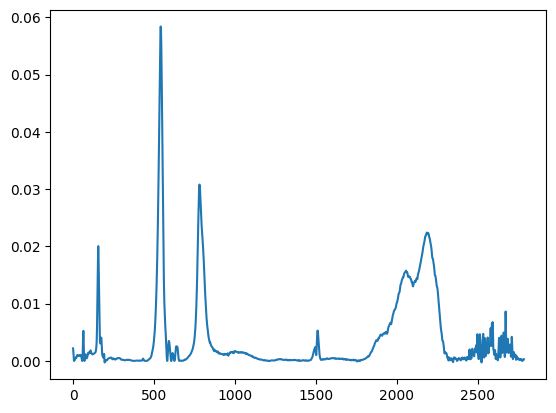

In [130]:
plt.plot(corrections[0])

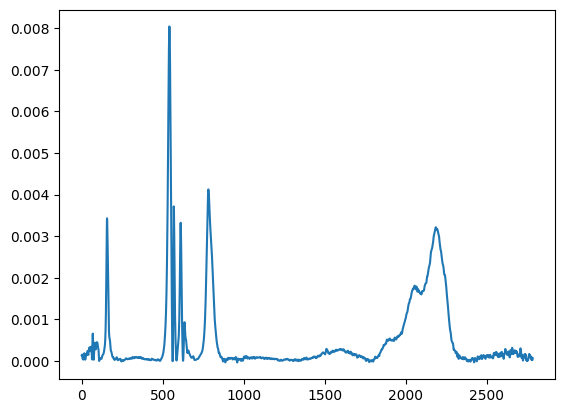

In [79]:
plt.plot(y - mu - W @ nu)

In [87]:


def pb_map(y, mu, W, tau, sigma, gamma, mit=None, verbose=False):
    x = cp.Variable(W.shape[1])
    prob = cp.Problem(
        cp.Minimize(
            cp.sum(0.5 * cp.abs(y - mu - W @ x) + (tau - 0.5) * (y - mu - W @ x))
            + 0.5 * sigma * cp.sum_squares(x/gamma)
        )
    )

    prob.solve(solver=cp.CLARABEL, verbose=verbose)

    return mu + W @ x.value, x.value